In [9]:
%run NN_defs.ipynb

import time, os, random
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

seed = 42
ns   = 300
nz   = 640
Lz   = 10 ; tf = 20
k1   = 1.0; k2 = 2.0
d_in = 4
tol = 5e-08
# rebuild_nn() restores from out_file; dat_file supplies the same points
out_file = f'./model/2layer_ns{ns}_tol{tol}_tag.pt'
dat_file = f'./data/2layer_interpol_ns{ns}_tagged.pt'

# IMPORTANT: rebuild, don't build fresh
start_new_nn = 0

random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = 'cuda'
print(f'model file : {out_file}')
print(f'data file  : {dat_file}')
print(f'exists     : model={os.path.exists(out_file)}  data={os.path.exists(dat_file)}')

model file : ./model/2layer_ns300_tol5e-08_tag.pt
data file  : ./data/2layer_interpol_ns300_tagged.pt
exists     : model=True  data=True


In [25]:
 #Load model A - New interface
dat_A = torch.load(out_file, weights_only=True)
for key in dat_A:
    globals()[key] = dat_A[key]
model_A, opt_A = rebuild_nn()
model_A = model_A.to(device)
model_A.eval()

# Load model B — Trail B
dat_B = torch.load(f'./model/2layer_ns{ns}_tol5e-08_reg.pt', weights_only=True)
for key in dat_B:
    globals()[key] = dat_B[key]
model_B, opt_B = rebuild_nn()
model_B = model_B.to(device)
model_B.eval()

# Load model C — Trail C
dat_C = torch.load(f'./model/2layer_ns{ns}_tol5e-08_class.pt', weights_only=True)
for key in dat_C:
    globals()[key] = dat_C[key]
model_C, opt_C = rebuild_nn()
model_C = model_C.to(device)
model_C.eval()

Net(
  (layers): ModuleList(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1-3): 3 x Linear(in_features=64, out_features=64, bias=True)
  )
  (out): Linear(in_features=64, out_features=1, bias=True)
)

In [63]:
# Load Data
trn_dat = torch.load(dat_file, weights_only=True)

stau = trn_dat['stau']
W = trn_dat['W']
kratio = trn_dat['kratio']
z_disv = trn_dat['zdis']
tag = trn_dat['tag']

## Model A - Trained with a tag 

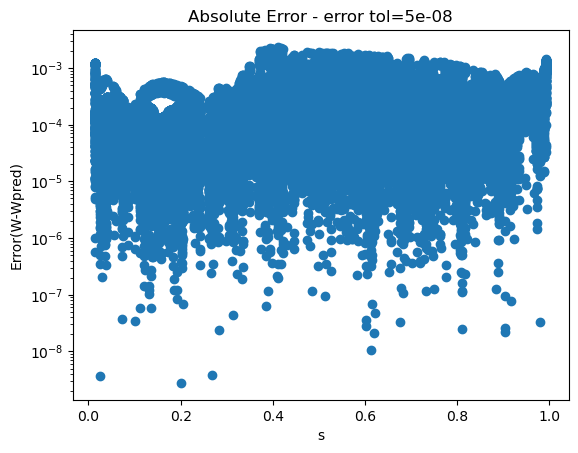

In [64]:

train = torch.stack([stau[:,0],stau[:,1], kratio, z_disv,tag], dim=-1)

xtrainA = train.to(torch.float64)
output = model_A(xtrainA)


errorA = torch.abs(W-output)

plt.scatter(stau[:,0].cpu().detach().numpy(),errorA.cpu().detach().numpy())
plt.yscale('log'); plt.xlabel('s');plt.ylabel('Error(W-Wpred)') ; plt.title(f'Absolute Error - error tol={tol}')
plt.show()


[1] Sampling box:
    s   ~ U(0.01, 1.0)
    tau ~ U(0.047619, 1.0)   (tau_lo = 1/(1+tf), tf = 20)


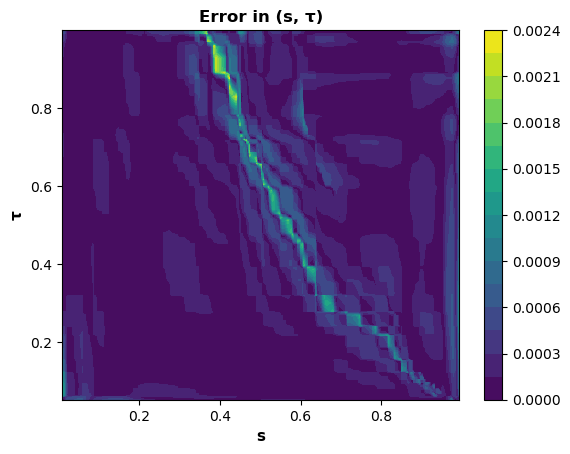

In [65]:
s_lo,  s_hi  = 0.01, 1.0
tau_lo, tau_hi = 1.0 / (1.0 + tf), 1.0
n_tau = 150 
gen   = torch.Generator(device=device).manual_seed(seed)
print(f'\n[1] Sampling box:')
print(f'    s   ~ U({s_lo}, {s_hi})')
print(f'    tau ~ U({tau_lo:.6f}, {tau_hi})   (tau_lo = 1/(1+tf), tf = {tf})')

# ---- Random uniform, sorted (sorting keeps the contour plots clean) ----
s_1d   = torch.sort(s_lo   + (s_hi   - s_lo  ) * torch.rand(ns,   device=device, generator=gen, dtype=torch.float64)).values
tau_1d = torch.sort(tau_lo + (tau_hi - tau_lo) * torch.rand(n_tau, device=device, generator=gen, dtype=torch.float64)).values


errorA= errorA.reshape(len(s_1d),len(tau_1d))
contour = plt.contourf(s_1d.cpu().detach().numpy(),tau_1d.cpu().detach().numpy(),errorA.T.cpu().detach().numpy(), levels=20, cmap='viridis')
plt.xlabel('s', fontsize=11, fontweight='bold')
plt.ylabel('τ', fontsize=11, fontweight='bold')
plt.title('Error in (s, τ)', fontsize=12, fontweight='bold')
plt.colorbar()

## Model B - Regular Interpolation Model -No Smoothing -

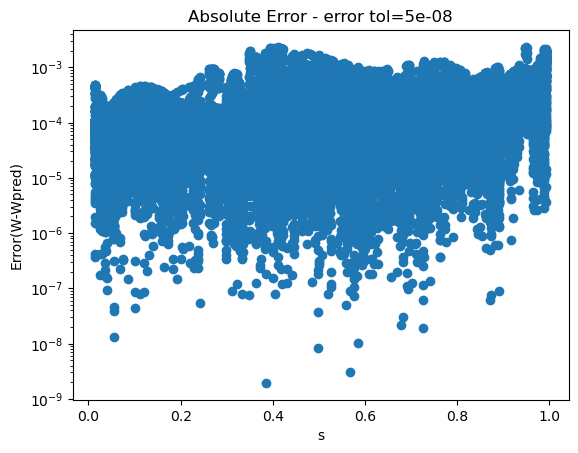

In [66]:
trainB = torch.stack([stau[:,0],stau[:,1], kratio, z_disv], dim=-1)

xtrainB = trainB.to(torch.float64)
outputB = model_B(xtrainB)


errorB = torch.abs(W-outputB)

plt.scatter(stau[:,0].cpu().detach().numpy(),errorB.cpu().detach().numpy())
plt.yscale('log'); plt.xlabel('s');plt.ylabel('Error(W-Wpred)') ; plt.title(f'Absolute Error - error tol={tol}')
plt.show()

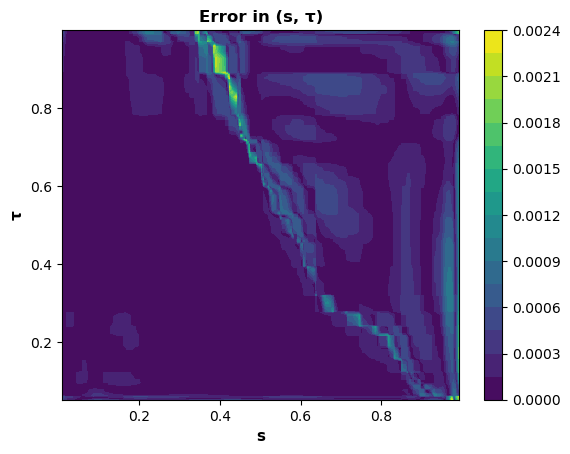

In [67]:
errorB= errorB.reshape(len(s_1d),len(tau_1d))
contour = plt.contourf(s_1d.cpu().detach().numpy(),tau_1d.cpu().detach().numpy(),errorB.T.cpu().detach().numpy(), levels=20, cmap='viridis')
plt.xlabel('s', fontsize=11, fontweight='bold')
plt.ylabel('τ', fontsize=11, fontweight='bold')
plt.title('Error in (s, τ)', fontsize=12, fontweight='bold')
plt.colorbar()

## Pre Classified tagged -Model C-

In [68]:
trn_c = torch.load(f'./data/2layer_interpol_ns{ns}_classified.pt', weights_only=True)
stauC = trn_c['stau']
W_C = trn_c['W']
kratioC = trn_c['kratio']
z_disvC = trn_c['zdis']
tagC = trn_c['newtag']

trainC = torch.stack([stauC[:,0],stauC[:,1], kratioC, z_disvC,tagC], dim=-1)

xtrainC = trainC.to(torch.float64)
outputC = model_C(xtrainC)

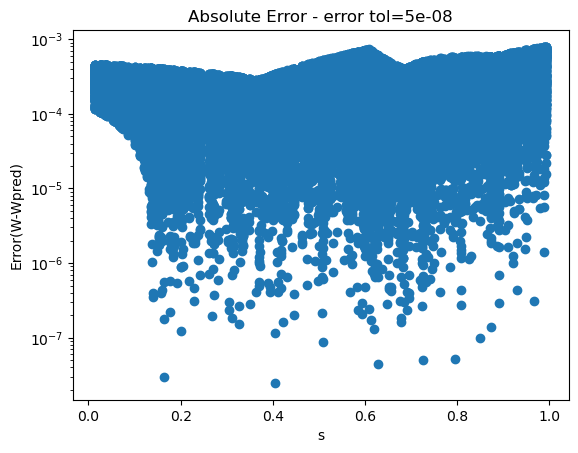

In [69]:
errorC = torch.abs(W_C-outputC)

plt.scatter(stauC[:,0].cpu().detach().numpy(),errorC.cpu().detach().numpy())
plt.yscale('log'); plt.xlabel('s');plt.ylabel('Error(W-Wpred)') ; plt.title(f'Absolute Error - error tol={tol}')
plt.show()

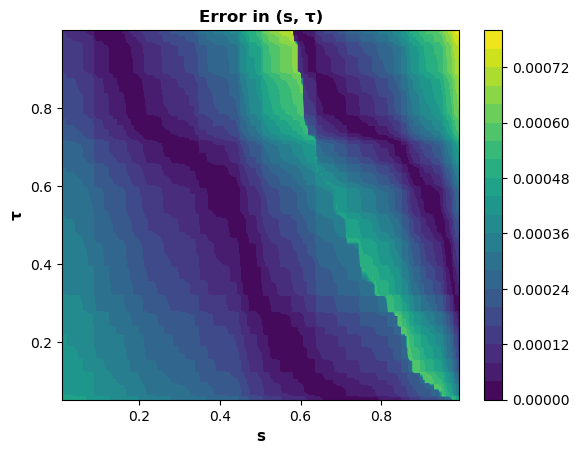

In [70]:
errorC= errorC.reshape(len(s_1d),len(tau_1d))
contour = plt.contourf(s_1d.cpu().detach().numpy(),tau_1d.cpu().detach().numpy(),errorC.T.cpu().detach().numpy(), levels=20, cmap='viridis')
plt.xlabel('s', fontsize=11, fontweight='bold')
plt.ylabel('τ', fontsize=11, fontweight='bold')
plt.title('Error in (s, τ)', fontsize=12, fontweight='bold')
plt.colorbar()